# MLQA-TSR — EDA, Training & Evaluation Demo

Đồ án môn **Máy học nâng cao** — nâng cấp baseline VLSP 2025 "MLQA-TSR" (Legal QA về luật giao thông Việt Nam)
từ rule-based/hash sang các mô hình học máy thật (Logistic Regression), có huấn luyện, đánh giá và so sánh
với baseline gốc trên tập validation cố định (tách từ 530 câu hỏi có nhãn của BTC).

**Phạm vi**: chỉ nhánh QA văn bản (Task 1 — truy hồi điều luật, Task 2 — trả lời Yes/No và trắc nghiệm).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_from_root, flatten_laws
from src.qa_model import normalize_label, build_law_lookup, build_content_vectorizer, YesNoClassifier, ChoiceScorer
from src.retriever_tfidf import TFIDFRetriever
from src.retriever_bm25 import BM25Retriever
from src.retrieval_eval import evaluate_retriever
from src.qa_rules import answer as rule_based_answer
from scripts.train import clean_train_examples, split_examples, train_yesno, train_mc, build_retriever

# Màu theo palette chuẩn: xanh dương = baseline, xanh ngọc (aqua) = model mới, vàng = ablation
COLOR_BASELINE = "#2a78d6"
COLOR_MODEL = "#1baf7a"
COLOR_ABLATION = "#eda100"
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#52514e"

DATASET_ROOT = r"..\..\vlsp_dataset\VLSP 2025 - MLQA-TSR Data Release"
cfg = yaml.safe_load(open("../configs/config.yaml", encoding="utf-8"))


## 1. Nạp dữ liệu

In [2]:
laws, examples = load_from_root(DATASET_ROOT, split="train")
law_items = flatten_laws(laws)
law_lookup = build_law_lookup(law_items)
print(f"So dieu luat: {len(law_items)}")
print(f"So cau hoi co nhan (train_data): {len(examples)}")
examples, dropped_ids = clean_train_examples(examples)
print(f"Loai {len(dropped_ids)} vi du nhan loi: {dropped_ids}")


So dieu luat: 402
So cau hoi co nhan (train_data): 530
Loai 1 vi du nhan loi: ['train_112']


## 2. Phân tích khám phá dữ liệu (EDA)

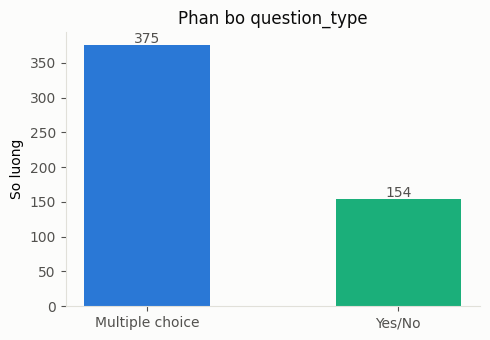

In [3]:
df = pd.DataFrame([{
    "id": ex["id"],
    "question_type": ex.get("question_type"),
    "answer": normalize_label(ex.get("answer", "")),
    "question_len_chars": len(ex.get("question", "")),
    "question_len_tokens": len(ex.get("question", "").split()),
} for ex in examples])

type_counts = df["question_type"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.bar(type_counts.index, type_counts.values, color=[COLOR_BASELINE, COLOR_MODEL], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, str(int(b.get_height())),
            ha="center", color=TEXT_COLOR, fontsize=10)
ax.set_title("Phan bo question_type", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
ax.tick_params(colors=TEXT_COLOR)
ax.set_ylabel("So luong")
plt.tight_layout()
plt.show()


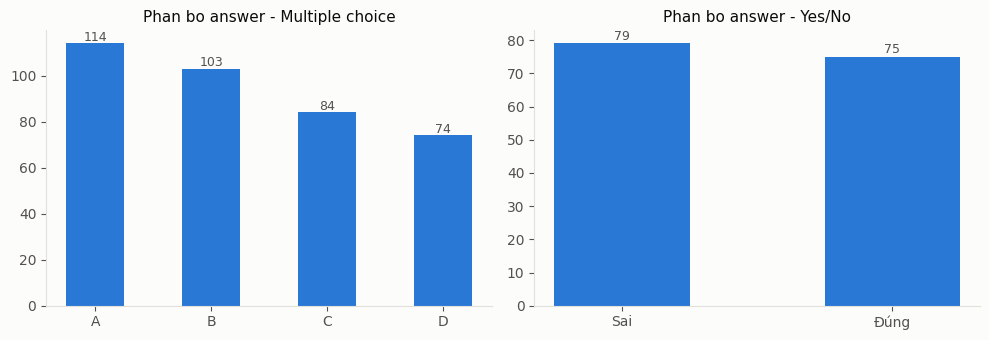

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), facecolor="#fcfcfb")
for ax, qtype in zip(axes, ["Multiple choice", "Yes/No"]):
    ax.set_facecolor("#fcfcfb")
    sub = df[df["question_type"] == qtype]["answer"].value_counts().sort_index()
    bars = ax.bar(sub.index, sub.values, color=COLOR_BASELINE, width=0.5)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, str(int(b.get_height())),
                ha="center", color=TEXT_COLOR, fontsize=9)
    ax.set_title(f"Phan bo answer - {qtype}", color="#0b0b0b", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
plt.tight_layout()
plt.show()


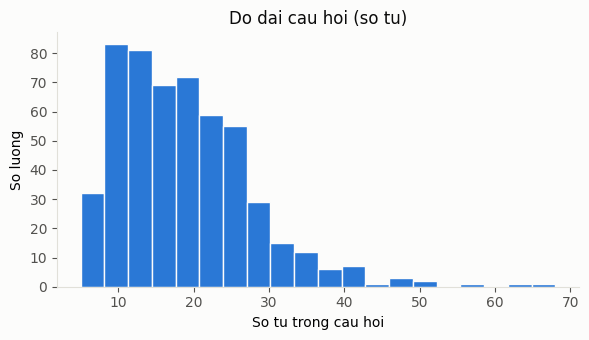

count    529.000000
mean      18.837429
std        8.997897
min        5.000000
25%       12.000000
50%       17.000000
75%       24.000000
max       68.000000
Name: question_len_tokens, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.hist(df["question_len_tokens"], bins=20, color=COLOR_BASELINE, edgecolor="#fcfcfb")
ax.set_title("Do dai cau hoi (so tu)", color="#0b0b0b")
ax.set_xlabel("So tu trong cau hoi")
ax.set_ylabel("So luong")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
ax.tick_params(colors=TEXT_COLOR)
plt.tight_layout()
plt.show()
print(df["question_len_tokens"].describe())


In [6]:
print("Vi du 1 dieu luat trong corpus:\n")
sample = law_items[0]
print(f"law_id={sample['law_id']}  article_id={sample['article_id']}")
print(sample["content"][:500])


Vi du 1 dieu luat trong corpus:

law_id=QCVN 41:2024/BGTVT  article_id=1
Phạm vi điều chỉnh
Quy chuẩn này quy định về báo hiệu đường bộ bao gồm: đèn tín hiệu giao thông; biển báo hiệu đường bộ; vạch kẻ đường và các dấu hiệu khác trên mặt đường; cọc tiêu, tường bảo vệ, rào chắn, đinh phản quang, tiêu phản quang, cột Km, cọc H; thiết bị âm thanh báo hiệu đường bộ.
Quy chuẩn này quy định về báo hiệu đường bộ áp dụng cho tất cả các tuyến đường bộ trong mạng lưới đường bộ Việt Nam, các đường nằm trong hệ thống đường bộ tham gia Điều ước quốc tế mà Việt Nam là thành viên (


## 3. Chia train/val

Chia ở cấp độ câu hỏi (id), stratify theo `question_type`, `seed=42`, `test_size=0.2` — dùng lại đúng logic
trong `scripts/train.py` để đảm bảo notebook và script CLI dùng cùng 1 tập validation.

In [7]:
train_ex, val_ex = split_examples(examples, val_size=cfg["model"]["val_size"], seed=cfg["model"]["seed"])
print(f"Train: {len(train_ex)}  Val: {len(val_ex)}")


Train: 423  Val: 106


## 4. Task 1 — Retrieval: TF-IDF vs BM25

In [8]:
top_k = cfg["retriever"]["top_k"]
max_law_chars = cfg["retriever"]["max_law_chars"]

tfidf_retriever = TFIDFRetriever(law_items, max_law_chars=max_law_chars)
bm25_retriever = BM25Retriever(law_items, max_law_chars=max_law_chars)
content_vectorizer = build_content_vectorizer(law_items, max_law_chars=max_law_chars)

retrieval_rows = []
for name, retriever in [("TF-IDF", tfidf_retriever), ("BM25", bm25_retriever)]:
    m = evaluate_retriever(retriever, val_ex, ks=(1, 3, 5))
    retrieval_rows.append({"method": name, **m})
retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df


,method,recall@1,recall@3,recall@5,mrr
0,TF-IDF,0.169811,0.273585,0.311321,0.225943
1,BM25,0.113208,0.198113,0.226415,0.155503


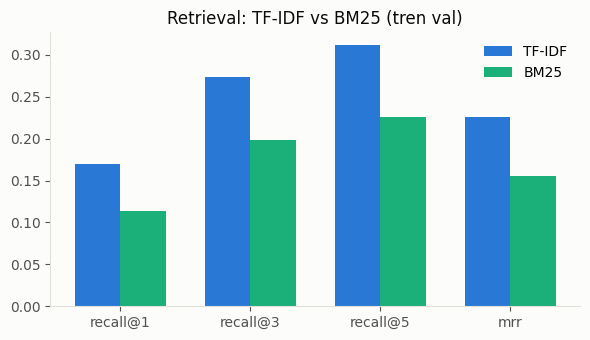

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
x = ["recall@1", "recall@3", "recall@5", "mrr"]
width = 0.35
positions = range(len(x))
ax.bar([p - width/2 for p in positions], retrieval_df.iloc[0][x], width, label="TF-IDF", color=COLOR_BASELINE)
ax.bar([p + width/2 for p in positions], retrieval_df.iloc[1][x], width, label="BM25", color=COLOR_MODEL)
ax.set_xticks(list(positions))
ax.set_xticklabels(x)
ax.set_title("Retrieval: TF-IDF vs BM25 (tren val)", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
ax.tick_params(colors=TEXT_COLOR)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 5. Task 2a — Yes/No: Logistic Regression vs baseline keyword-matching

In [10]:
yesno_model, n_yn = train_yesno(train_ex)
print(f"Trained tren {n_yn} vi du Yes/No")

yn_val = [ex for ex in val_ex if (ex.get("question_type") or "").strip().lower() == "yes/no"]
yn_gold = [normalize_label(ex["answer"]) for ex in yn_val]
yn_questions = [ex["question"] for ex in yn_val]

yn_baseline_pred = [normalize_label(rule_based_answer(q, "Yes/No",
                        yes_keywords=cfg["qa_rules"]["yes_keywords"],
                        no_keywords=cfg["qa_rules"]["no_keywords"])) for q in yn_questions]
yn_model_pred = [normalize_label(p) for p in yesno_model.predict(yn_questions)]

from sklearn.metrics import accuracy_score, f1_score
yn_rows = []
for name, preds in [("Baseline (keyword rules)", yn_baseline_pred), ("YesNoClassifier (LogReg)", yn_model_pred)]:
    yn_rows.append({"method": name,
                     "accuracy": accuracy_score(yn_gold, preds),
                     "macro_f1": f1_score(yn_gold, preds, average="macro", zero_division=0)})
yn_df = pd.DataFrame(yn_rows)
yn_df


Trained tren 123 vi du Yes/No


,method,accuracy,macro_f1
0,Baseline (keyword rules),0.612903,0.380000
1,YesNoClassifier (LogReg),0.774194,0.774194


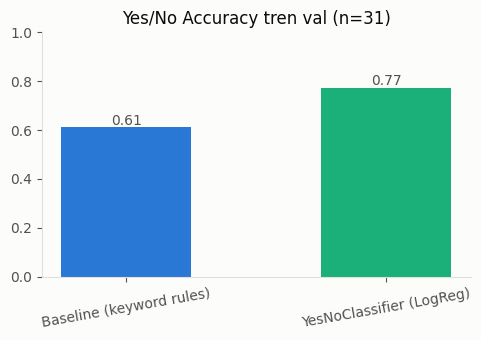

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
colors = [COLOR_BASELINE, COLOR_MODEL]
bars = ax.bar(yn_df["method"], yn_df["accuracy"], color=colors, width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}",
            ha="center", color=TEXT_COLOR, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title(f"Yes/No Accuracy tren val (n={len(yn_val)})", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
ax.tick_params(colors=TEXT_COLOR)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 6. Task 2b — Multiple choice: pointwise scoring (Logistic Regression) vs baseline hash

So sánh thêm 1 **ablation**: có/không thêm đặc trưng one-hot vị trí đáp án (A/B/C/D), vì phân bố nhãn thật
lệch (A nhiều hơn D) nên model có thể học "prior" vị trí — cần kiểm chứng xem việc này có thực sự giúp ích
trên tập val hay không (rủi ro overfit vì chỉ có ~300 ví dụ train).

In [12]:
mc_model, n_mc = train_mc(train_ex, tfidf_retriever, law_lookup, content_vectorizer, False, top_k, max_law_chars)
mc_model_letter, _ = train_mc(train_ex, tfidf_retriever, law_lookup, content_vectorizer, True, top_k, max_law_chars)
print(f"Trained tren {n_mc} vi du Multiple choice")

mc_val = [ex for ex in val_ex if (ex.get("question_type") or "").strip().lower().startswith("multiple")]
mc_gold = [normalize_label(ex["answer"]).upper() for ex in mc_val]
mc_baseline_pred = [normalize_label(rule_based_answer(ex["question"], "Multiple choice")).upper() for ex in mc_val]
mc_model_pred = [normalize_label(mc_model.predict_example(ex, tfidf_retriever, law_lookup, content_vectorizer,
                    top_k=top_k, max_ctx_chars=max_law_chars)).upper() for ex in mc_val]
mc_model_letter_pred = [normalize_label(mc_model_letter.predict_example(ex, tfidf_retriever, law_lookup, content_vectorizer,
                    top_k=top_k, max_ctx_chars=max_law_chars)).upper() for ex in mc_val]

mc_rows = []
for name, preds in [("Baseline (MD5 hash)", mc_baseline_pred),
                     ("ChoiceScorer (no letter)", mc_model_pred),
                     ("ChoiceScorer (+letter, ablation)", mc_model_letter_pred)]:
    mc_rows.append({"method": name, "accuracy": accuracy_score(mc_gold, preds)})
mc_df = pd.DataFrame(mc_rows)
mc_df


Trained tren 300 vi du Multiple choice


,method,accuracy
0,Baseline (MD5 hash),0.160000
1,ChoiceScorer (no letter),0.400000
2,"ChoiceScorer (+letter, ablation)",0.266667


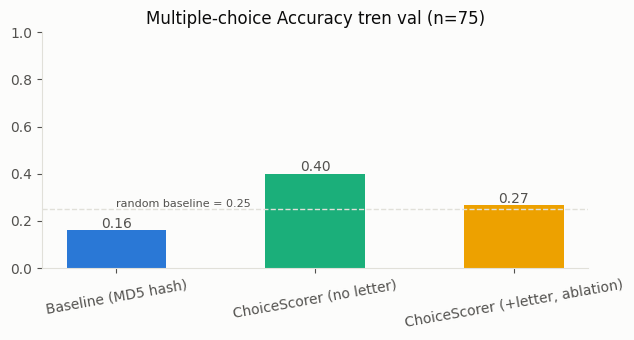

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
colors = [COLOR_BASELINE, COLOR_MODEL, COLOR_ABLATION]
bars = ax.bar(mc_df["method"], mc_df["accuracy"], color=colors, width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}",
            ha="center", color=TEXT_COLOR, fontsize=10)
ax.axhline(0.25, color=GRID_COLOR, linestyle="--", linewidth=1)
ax.text(0, 0.26, "random baseline = 0.25", color=TEXT_COLOR, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title(f"Multiple-choice Accuracy tren val (n={len(mc_val)})", color="#0b0b0b")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID_COLOR)
ax.tick_params(colors=TEXT_COLOR)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 7. Ví dụ định tính trên tập validation

In [14]:
rows = []
for ex, gold, base, model in list(zip(mc_val, mc_gold, mc_baseline_pred, mc_model_pred))[:5]:
    rows.append({
        "question": ex["question"][:70] + ("..." if len(ex["question"]) > 70 else ""),
        "gold": gold, "baseline": base, "model": model, "model_dung": model == gold,
    })
pd.DataFrame(rows)


,question,gold,baseline,model,model_dung
0,"Biển báo hình chữ nhật, có nền xanh, chữ trắng...",B,A,A,False
1,Biển báo màu xanh trong hình cho ta biết điều gì?,B,C,D,False
2,Trên tuyến đường này biển báo giao thông này k...,A,C,C,False
3,Biển báo trong ảnh thuộc loại biển báo nào?,B,D,B,True
4,Khoảng cách từ vị trí đặt biển báo đến Thị xã ...,B,D,C,False


## 8. Kết luận

- **Retrieval (Task 1)**: TF-IDF và BM25 đều là baseline IR cổ điển hợp lệ; kết quả Recall@k/MRR ở trên cho
  thấy phương pháp nào phù hợp hơn với corpus luật giao thông này.
- **Yes/No (Task 2a)**: Logistic Regression trên đặc trưng TF-IDF của câu hỏi cải thiện rõ so với baseline
  so khớp từ khoá cứng.
- **Multiple choice (Task 2b)**: pointwise scoring bằng Logistic Regression vượt xa baseline hash (~ngẫu
  nhiên 25%). Ablation vị trí đáp án cho thấy rủi ro overfit khi tập train nhỏ (~300 ví dụ).
- **Hạn chế**: chỉ có 530 ví dụ có nhãn (không có nhãn cho public_test để đánh giá cuối); chưa dùng
  sentence-embedding/deep learning; multiple-choice mới ở dạng pointwise chứ chưa phải full learning-to-rank.
- **Hướng phát triển**: sentence-embedding đa ngôn ngữ (SBERT/PhoBERT) cho retriever, cross-encoder rerank,
  k-fold cross-validation để giảm phương sai đánh giá với tập nhỏ.
